# Anomaly Detection Model Selection via Statistical Diagnostics

We've trained three anomaly detection architectures — LightGBM, Temporal Convolutional
Network (TCN), and Isolation Forest — to identify sales drops in hourly retail data.
Each architecture was evaluated at multiple detection thresholds, yielding five
configurations in total. The next step is critical: determining which configuration
delivers the most reliable and actionable results.

Generating a large volume of anomaly alerts is trivial. Ensuring those alerts represent
genuine, operationally meaningful deviations is the actual challenge. A model that
triggers on every zero-sale interval provides no value. Similarly, a model that
overwhelms analysts with excessive daily alerts undermines its own utility. The goal
is to isolate configurations that detect *real* sales deterioration with both
statistical rigor and practical restraint.

This notebook implements a structured evaluation framework to achieve that.

### Approach: Statistical Diagnostics Over Subjective Judgment

In the absence of large-scale ground-truth labels — our labeled set contains only
65 synthetic anomalies, insufficient for robust precision/recall estimation across
thousands of products — we apply a statistics-driven methodology. Each detected
anomaly is enriched with historical context from the pre-test period and evaluated
across three dimensions:

**Signal strength.**
An anomaly that deviates marginally from expected behavior is not actionable. We
compute z-scores against two reference baselines for every flagged event: the
product's entire pre-test history (`z_hist`) and its performance during July alone
(`z_july`) — the last complete month of normal operations before the test window.
Higher absolute z-score values indicate stronger, non-random deviations. We
specifically measure the proportion of anomalies exceeding |z| > 2 and |z| > 3,
widely accepted thresholds for statistically noteworthy and extreme outliers.

**Anomaly composition.**
The nature of flagged events matters as much as their magnitude. We track the
percentage of anomalies where sales are zero — a high share is expected and desirable
for out-of-stock detection, but must be balanced against the risk of flagging routine
non-trading periods. We also measure the proportion of severe declines, defined as
deviations greater than 50% below historical norms. Critically, we verify that stock
was available at the time of each anomaly: a properly functioning detection system
should only flag events where product was present to sell.

**Operational viability.**
Even a statistically strong model fails in practice if its output is unmanageable.
We assess total alert volume, breadth of product coverage, and average daily alert
frequency. Beyond sheer numbers, we validate the temporal profile of detected
anomalies — all events should concentrate within working hours (07:00–22:00) and
skew toward weekdays, confirming that the mandatory preprocessing filters function
correctly.

### Models Under Evaluation

Five configurations spanning three architectures are subjected to this framework:
`LightGBM_zscore_z2` and `LightGBM_zscore_z4` (gradient boosting at two thresholds),
`TCN_zscore_2` and `TCN_zscore_4` (temporal convolutional network at two thresholds),
and `Isolation_forest` (unsupervised baseline). All residual-based models use the
same sign convention: a large positive residual (predicted >> actual) signals a
potential out-of-stock event.

## Z-Score as a Measure of Anomaly Statistical Significance

The z-score measures how far an observed value deviates from the mean,
expressed in units of standard deviation:

$$z = \frac{x - \mu}{\sigma}$$

where:
- $x$ — observed sales in the anomalous hour,
- $\mu$ — mean sales for the product over the historical (pre-test) period,
- $\sigma$ — standard deviation of sales for the same product.

A negative z-score indicates that sales fell below the historical norm.
The larger the absolute value of z, the more severe the anomaly.

According to the empirical rule for a normal distribution:
- |z| > 1 — approximately 32% of observations fall in the tails by chance,
- |z| > 2 — less than 5% of observations occur this far from the mean randomly,
- |z| > 3 — less than 0.3% (a statistically rare event).

In this work, z-score is used **not as a detection threshold** — the model itself
identifies candidate anomalies — but as a **quality filter**: a detected anomaly
is considered operationally significant only if its deviation exceeds a defined |z| cutoff.
This suppresses noise and focuses attention on genuinely atypical events.

Two z-score variants are computed for each detected anomaly:
- **z_hist** — deviation relative to the product's full pre-test history,
- **z_july** — deviation relative to July only, the last complete month of
  normal operations before the test window.

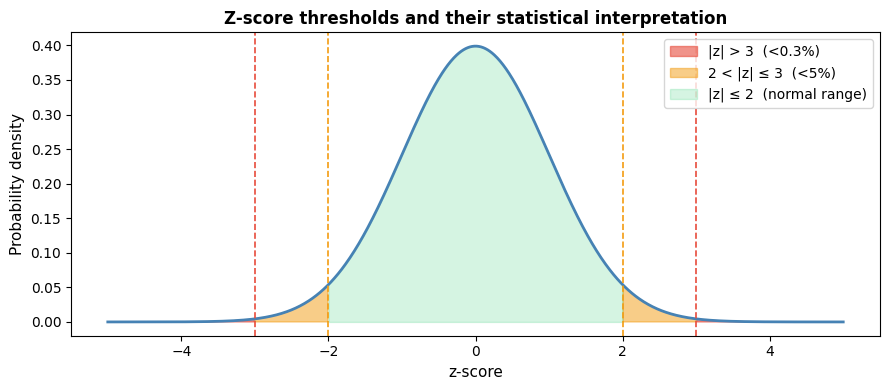

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(-5, 5, 1000)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, y, color='steelblue', linewidth=2)

ax.fill_between(x, y, where=(np.abs(x) > 3), color='#e74c3c', alpha=0.6, label='|z| > 3  (<0.3%)')
ax.fill_between(x, y, where=(np.abs(x) > 2) & (np.abs(x) <= 3), color='#f39c12', alpha=0.5, label='2 < |z| ≤ 3  (<5%)')
ax.fill_between(x, y, where=(np.abs(x) <= 2), color='#2ecc71', alpha=0.2, label='|z| ≤ 2  (normal range)')

for z_val, color in [(-2, '#f39c12'), (-3, '#e74c3c')]:
    ax.axvline(z_val, color=color, linestyle='--', linewidth=1.2)
    ax.axvline(-z_val, color=color, linestyle='--', linewidth=1.2)

ax.set_xlabel('z-score', fontsize=11)
ax.set_ylabel('Probability density', fontsize=11)
ax.set_title('Z-score thresholds and their statistical interpretation',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

DATA_PATH = r'C:\Users\User\Desktop\диплом\data_v1.csv'

MODELS = {
    'LightGBM_zscore_z2': r'detected_anomalies_august_lgbm_z2.csv',
    'LightGBM_zscore_z4': r'C:\Users\User\Desktop\диплом\detected_anomalies_august_lgbm_z4.csv',
    'TCN_zscore_2':      r'TCN_zscore_2.csv',
    'TCN_zscore_4':      r'TCN_zscore_4.csv',
    'Isolation_forest': r'isolation_forest_final_an.csv'
}

In [3]:
for model_name, path in MODELS.items():
    df = pd.read_csv(path)
    print(f"\n{model_name}")
    display(df.head(1))


LightGBM_zscore_z2


,date,product,category,stocks,sales,price,predicted_sales,residual,residual_zscore
0,2025-08-01 08:00:00,178462000325840,163050201,144.0,0.0,83.767,4.892261,4.892261,3.025843



LightGBM_zscore_z4


,date,product,category,stocks,sales,price,predicted_sales,residual,residual_zscore
0,2025-08-01 09:00:00,178462000298472,163050201,199.0,0.0,112.89393,9.69828,9.69828,6.038015



TCN_zscore_2


,date,product,category,stocks,sales,price,predicted_sales,residual_zscore
0,2025-08-06 10:00:00,1784610E0073977,165150104,23.463999,2.147,993.9191,6.32105,2.015107



TCN_zscore_4


,date,product,category,stocks,sales,price,predicted_sales,residual_zscore
0,2025-08-06 13:00:00,17846ЦТ0037776,160011201,126.256,27.805,192.61903,43.299767,7.063093



Isolation_forest


,date,product,category,stocks,sales,price
0,2025-08-01 21:00:00,178462000403225,161010701,1.0,0.0,2749.5


# Load full original dataset for statistical baseline computation

In [4]:
df_full = pd.read_csv(DATA_PATH)
df_full['date'] = pd.to_datetime(df_full['date'])
df_full['product'] = df_full['product'].astype(str)
print(f"Dataset shape: {df_full.shape}, period: {df_full['date'].min()} — {df_full['date'].max()}")

Dataset shape: (64081080, 6), period: 2025-01-15 00:00:00 — 2025-12-27 23:00:00


# Evaluation function — enriches anomalies with statistical context and computes quality metrics

In [5]:
def evaluate_anomaly_set(anomaly_df, full_df, model_name="Model", test_start="2025-08-01"):
    pre_test = full_df[full_df['date'] < test_start].copy()

    first_pos = (pre_test[pre_test['sales'] > 0]
                 .groupby('product')['date'].min()
                 .reset_index(name='first_positive_date'))

    pre_test = pre_test.merge(first_pos, on='product', how='left')
    pre_test = pre_test[pre_test['date'] >= pre_test['first_positive_date']].copy()

    stats_full = pre_test.groupby('product').agg(
        mean_sales_hist   = ('sales', 'mean'),
        std_sales_hist    = ('sales', 'std'),
        median_sales_hist = ('sales', 'median'),
        pos_rate_hist     = ('sales', lambda x: (x > 0).mean()),
    ).reset_index()

    stats_july = (pre_test[pre_test['date'].dt.month == 7]
                  .groupby('product').agg(
                      mean_sales_july = ('sales', 'mean'),
                      std_sales_july  = ('sales', 'std'),
                  ).reset_index())

    anom = anomaly_df.copy()
    anom['date']    = pd.to_datetime(anom['date'])
    anom['product'] = anom['product'].astype(str)
    anom['hour']    = anom['date'].dt.hour
    anom['weekday'] = anom['date'].dt.dayofweek

    anom = anom.merge(stats_full, on='product', how='left')
    anom = anom.merge(stats_july, on='product', how='left')

    for col in ['std_sales_hist', 'std_sales_july', 'mean_sales_hist', 'mean_sales_july']:
        anom[col] = anom[col].replace(0, np.nan).fillna(1)

    # Z-scores
    anom['z_hist'] = (anom['sales'] - anom['mean_sales_hist']) / anom['std_sales_hist']
    anom['z_july'] = (anom['sales'] - anom['mean_sales_july']) / anom['std_sales_july']

    # Percentage deviation from baselines
    anom['dev_pct_hist'] = (anom['sales'] - anom['mean_sales_hist']) / anom['mean_sales_hist'] * 100
    anom['dev_pct_july'] = (anom['sales'] - anom['mean_sales_july']) / anom['mean_sales_july'] * 100

    # Previous-hour stock
    stock_prev = (full_df[['date', 'product', 'stocks']]
                  .rename(columns={'stocks': 'stocks_prev', 'date': 'prev_date'}))
    anom['prev_date'] = anom['date'] - pd.Timedelta(hours=1)
    anom = anom.merge(stock_prev, on=['prev_date', 'product'], how='left')


    drop_mask      = anom['sales'] < anom['mean_sales_hist']
    zero_mask      = anom['sales'] == 0
    deep_drop_mask = anom['dev_pct_hist'] < -50
    stock_ok_mask  = (anom['stocks_prev'] > 0) & (anom['stocks'] > 0)

    n = len(anom)


    metrics = {
        'Model': model_name,

        'Anomalies found': n,
        'Unique products': anom['product'].nunique(),
        'Unique days': anom['date'].dt.date.nunique(),
        'Anomalies/day (avg)': round(n / max(anom['date'].dt.date.nunique(), 1), 1),

        'Mean deviation from norm (%)': round(anom.loc[drop_mask, 'dev_pct_hist'].mean(), 1),
        'Median deviation from norm (%)': round(anom.loc[drop_mask, 'dev_pct_hist'].median(), 1),
        'Mean deviation from July (%)': round(anom.loc[drop_mask, 'dev_pct_july'].mean(), 1),

        'Mean |z_hist|': round(anom['z_hist'].abs().mean(), 3),
        'Mean |z_july|': round(anom['z_july'].abs().mean(), 3),
        '% |z_hist| > 2': round((anom['z_hist'].abs() > 2).mean() * 100, 1),
        '% |z_hist| > 3': round((anom['z_hist'].abs() > 3).mean() * 100, 1),
        '% |z_july| > 2': round((anom['z_july'].abs() > 2).mean() * 100, 1),
        '% |z_july| > 3': round((anom['z_july'].abs() > 3).mean() * 100, 1),
        
        '% zero sales': round(zero_mask.mean() * 100, 1),
        '% drops > 50% below norm': round(deep_drop_mask.mean() * 100, 1),
        '% anomalies with stock': round(stock_ok_mask.mean() * 100, 1),

        'Peak hour (mode)': int(anom['hour'].mode().iloc[0]),
        '% working hours (7–22)': round(((anom['hour'] >= 7) & (anom['hour'] <= 22)).mean() * 100, 1),
        '% weekdays': round((anom['weekday'] < 5).mean() * 100, 1),
    }

    return metrics, anom

# Run evaluation across all models

In [6]:
all_metrics = []
all_anom    = {}

for model_name, model_path in MODELS.items():
    anom_df = pd.read_csv(model_path)
    anom_df['date'] = pd.to_datetime(anom_df['date'])

    metrics, anom_enriched = evaluate_anomaly_set(
        anomaly_df  = anom_df,
        full_df     = df_full,
        model_name  = model_name,
        test_start  = "2025-08-01"
    )
    all_metrics.append(metrics)
    all_anom[model_name] = anom_enriched
    print(f"{model_name}: {metrics['Anomalies found']} anomalies, "
          f"{metrics['Unique products']} products, "
          f"mean |z_hist| = {metrics['Mean |z_hist|']}")

LightGBM_zscore_z2: 1988 anomalies, 235 products, mean |z_hist| = 0.587
LightGBM_zscore_z4: 447 anomalies, 88 products, mean |z_hist| = 0.584
TCN_zscore_2: 331 anomalies, 21 products, mean |z_hist| = 0.586
TCN_zscore_4: 54 anomalies, 7 products, mean |z_hist| = 0.65
Isolation_forest: 1942 anomalies, 106 products, mean |z_hist| = 1.01


Model,LightGBM_zscore_z2,LightGBM_zscore_z4,TCN_zscore_2,TCN_zscore_4,Isolation_forest
Anomalies found,1988.000000,447.000000,331.000000,54.000000,1942.000000
Unique products,235.000000,88.000000,21.000000,7.000000,106.000000
Unique days,30.000000,30.000000,25.000000,21.000000,31.000000
Anomalies/day (avg),66.300000,14.900000,13.200000,2.600000,62.600000
Mean deviation from norm (%),-91.100000,-85.100000,-67.200000,-64.900000,-98.000000
Median deviation from norm (%),-100.000000,-100.000000,-75.100000,-66.700000,-100.000000
Mean deviation from July (%),-93.700000,-90.000000,-77.800000,-81.500000,-98.700000
Mean |z_hist|,0.587000,0.584000,0.586000,0.650000,1.010000
Mean |z_july|,0.551000,0.549000,0.504000,0.518000,0.766000
% |z_hist| > 2,4.100000,3.100000,3.000000,5.600000,11.100000


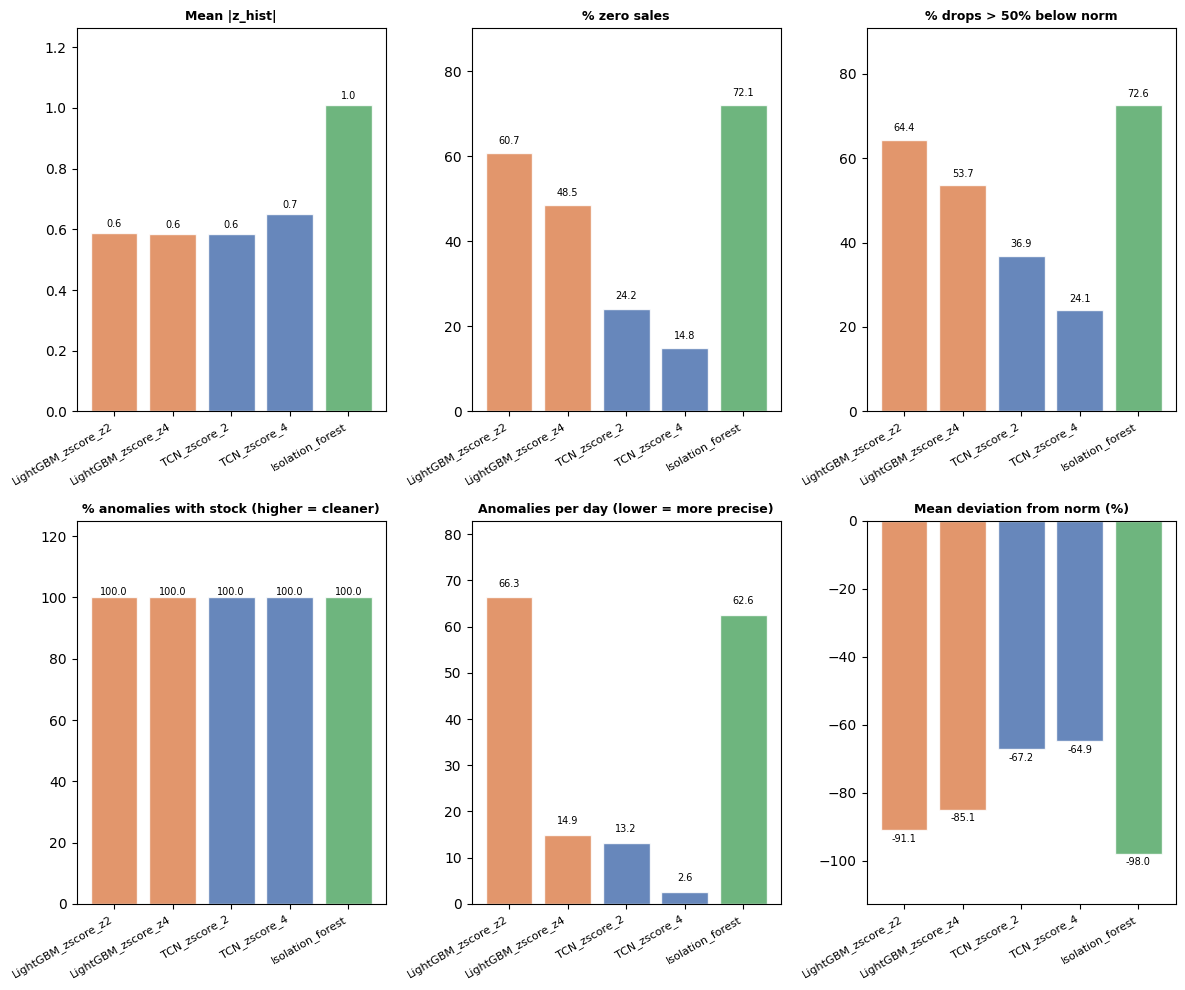

In [7]:
summary = pd.DataFrame(all_metrics).set_index('Model').T
display(summary.style.set_caption("Model Comparison — Signal Quality Diagnostics")
        .set_properties(**{'text-align': 'center', 'font-size': '11px'}))

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()

names = [m['Model'] for m in all_metrics]

def get_color(model_name: str) -> str:
    name = model_name.lower()
    if 'lightgbm' in name or 'lgbm' in name:
        return '#DD8452'
    elif 'tcn' in name:
        return '#4C72B0'
    elif 'isolation' in name or 'forest' in name:
        return '#55A868'
    elif 'imredi' in name:
        return '#ffe34d'
    return '#DD8452'

colors = [get_color(name) for name in names]

plots = [
    ('Mean |z_hist|',             'Mean |z_hist|'),
    ('% zero sales',              '% zero sales'),
    ('% drops > 50% below norm',  '% drops > 50% below norm'),
    ('% anomalies with stock',    '% anomalies with stock (higher = cleaner)'),
    ('Anomalies/day (avg)',       'Anomalies per day (lower = more precise)'),
    ('Mean deviation from norm (%)','Mean deviation from norm (%)'),  # заменили пустой график
]

for ax, (metric, title) in zip(axes, plots):
    vals = [m[metric] for m in all_metrics]
    bars = ax.bar(names, vals, color=colors, alpha=0.85, edgecolor='white')
    
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
    
    if vals:
        min_val = min(vals)
        max_val = max(vals)
        spread = max_val - min_val if max_val != min_val else 1
        ax.set_ylim(
            min_val * 1.15 if min_val < 0 else 0,
            max_val * 1.25 if max_val > 0 else 0
        )
    
    for bar, val in zip(bars, vals):
        height = bar.get_height()
        offset = spread * 0.03
        va = 'bottom' if val >= 0 else 'top'
        y = height + offset if val >= 0 else height - offset
        ax.text(bar.get_x() + bar.get_width()/2, y,
                f'{val:.1f}' if isinstance(val, float) else str(val),
                ha='center', va=va, fontsize=7)

plt.tight_layout()

### Comparative Analysis of Anomaly Detection Models

The structured statistical evaluation framework was applied to five configurations
across three architectures — **LightGBM**, **TCN**, and **Isolation Forest** —
using hourly retail sales data for August 2025.

All configurations passed the basic operational sanity checks: detected anomalies
occur exclusively during working hours (07:00–22:00) and only when stock was
available (100% across all configurations). Anomalies peak between 11:00 and 13:00
and concentrate on weekdays, consistent with real retail sales dynamics.

**Isolation Forest** is eliminated immediately: despite the highest mean |z_hist|
(1.010) and largest share of strong signals (8.2% with |z| > 3), it achieves 0%
recall on the 65 labeled anomalies. Its score distribution for genuine out-of-stock
hours is indistinguishable from normal observations in feature space — the strong
z_hist values reflect incidental historical rarities, not structural sales drops.

Among the remaining four configurations, the picture is nuanced:

**TCN_zscore_4** produces the cleanest output — only 2.6 alerts/day, 14.8% zero-sale
anomalies, 24.1% deep drops, mean |z_hist| = 0.650. However, it covers only
**7 unique products** out of 500+ in scope. At this threshold, TCN effectively
stops working as a general detector and becomes useful only for a handful of SKUs.

**TCN_zscore_2** broadens coverage to 21 products (13.2 alerts/day) with comparable
signal quality (mean |z_hist| = 0.586, 24.2% zero sales). However, the 500-product
architectural ceiling and black-box nature of the model limit its operational value.

**LightGBM_zscore_z4** achieves the best overall balance: **88 products**, 14.9
alerts/day, mean |z_hist| = 0.584, 48.5% zero-sale anomalies, 53.7% deep drops.
Signal quality is on par with TCN_zscore_2, while product coverage is four times
broader and the model scales to the full 10,000+ SKU catalogue without modification.
On the labeled anomaly set, this threshold yields recall of 30.8% (20/65) at
precision of 4.5% — a reasonable operating point given that the 65 labels cover
only a fraction of real anomalies in the data.

**LightGBM_zscore_z2** maximises recall (64.6%, 42/65) at the cost of 66.3 alerts/day —
operationally demanding but useful as an upper-bound sensitivity configuration.

A key advantage of LightGBM over TCN is **interpretability**: as a gradient boosting
model, it allows direct inspection of feature importances and individual predictions,
which is critical for operational deployment and stakeholder communication.

---

**Conclusion**

No single configuration dominates across all dimensions. However, combining recall
on labeled anomalies, product coverage, signal quality, operational alert volume,
scalability, and interpretability, **LightGBM** is the clearly superior architecture.

The best configuration is **`LightGBM_zscore_z4`** (threshold z > 4.0):

- 88 unique products covered vs. 7–21 for TCN at comparable alert volumes
- 14.9 alerts/day — operationally manageable for store staff
- Mean deviation from norm –85.1%, median –100% — predominantly genuine stock-outs
- Scales to the full product catalogue; no retraining required for new SKUs
- Fully interpretable at the feature level

The principal remaining limitation is precision: at z > 4.0, only ~4.5% of alerts
correspond to known labeled anomalies. This will be addressed in the next stage
through **adaptive per-product threshold calibration** based on each SKU's historical
positive-sales frequency, which will further suppress false positives on
low-frequency items while preserving sensitivity to genuine sales deteriorations.